In [3]:
# 1. Install required MIDI processing libraries
!pip install pretty_midi miditok

# 2. Core Deep Learning Library
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 3. Data Handling and Numerical Operations
import numpy as np
import pandas as pd

# 4. MIDI Processing
import pretty_midi
import miditok

# 5. Visualization and Utilities
import matplotlib.pyplot as plt
import os
import glob
import importlib.metadata

# Verify if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Check library versions correctly
print(f"PyTorch version: {torch.__version__}")
try:
    print(f"MidiTok version: {importlib.metadata.version('miditok')}")
except importlib.metadata.PackageNotFoundError:
    print("MidiTok is installed but version couldn't be retrieved via metadata.")

Using device: cuda
PyTorch version: 2.10.0+cu128
MidiTok version: 3.0.6.post1


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success: Metadata loaded from Google Drive.


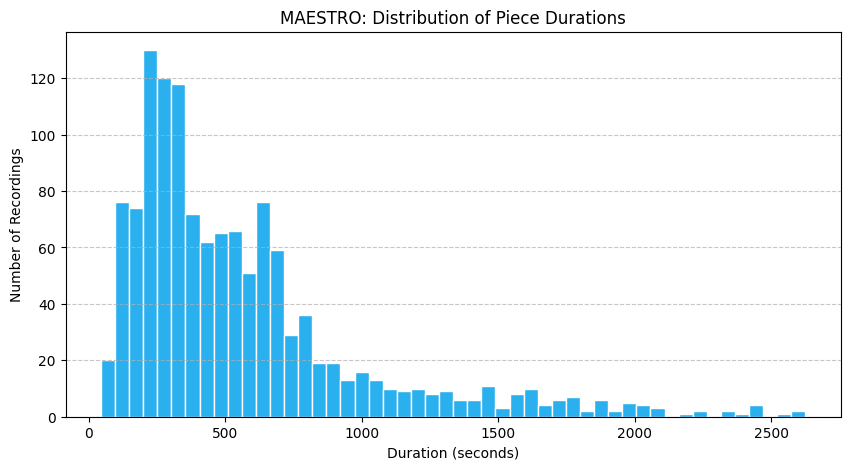

Analyzing MIDI files from Google Drive...


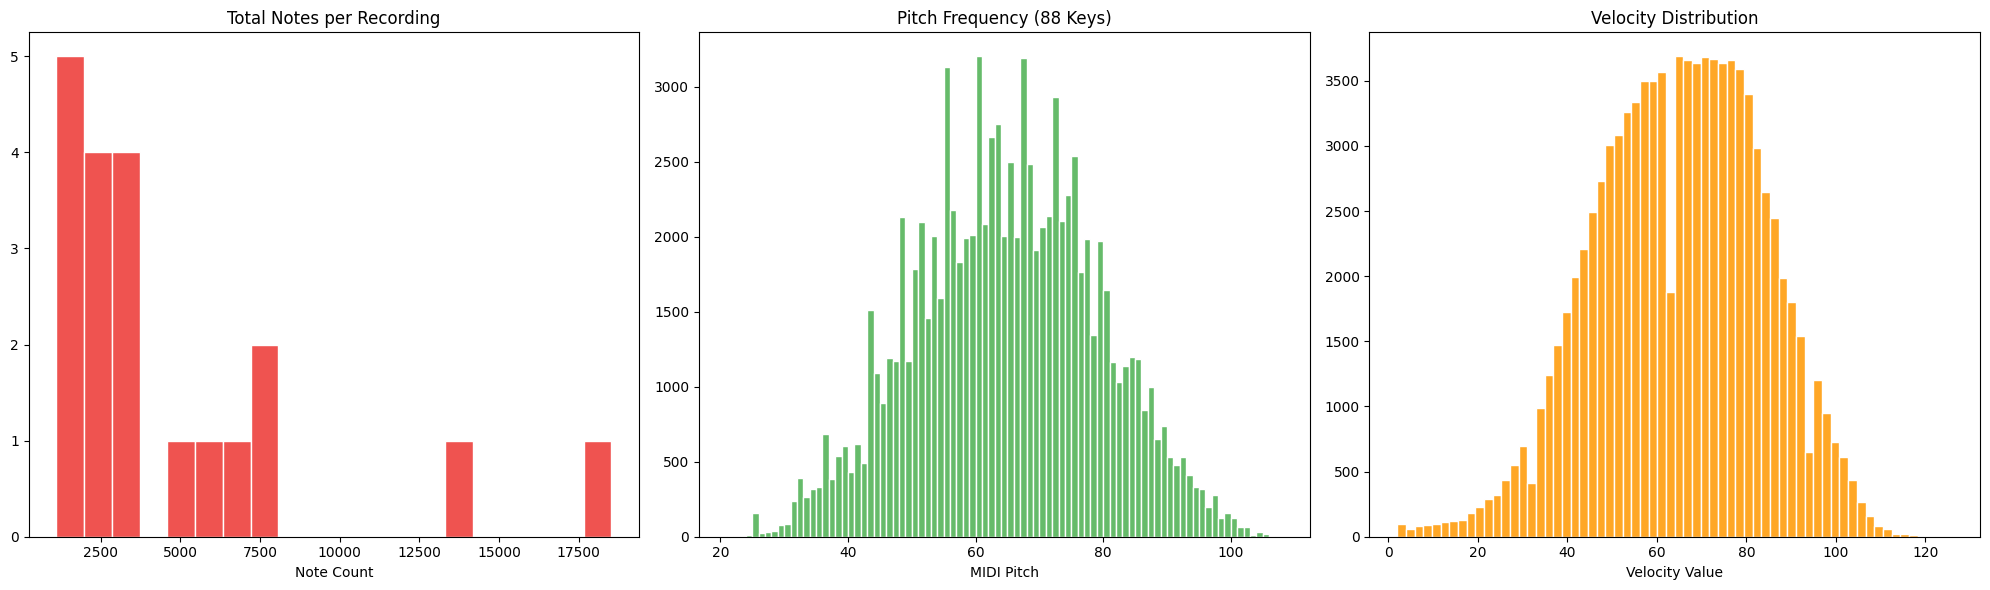


--- Piano-Roll Sparsity Analysis ---
File: 2009/MIDI-Unprocessed_14_R1_2009_01-05_ORIG_MID--AUDIO_14_R1_2009_14_R1_2009_03_WAV.midi
Sparsity: 98.97% zero cells
File: 2009/MIDI-Unprocessed_11_R1_2009_01-05_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_03_WAV.midi
Sparsity: 96.58% zero cells


In [4]:
from google.colab import drive

# --- 1. MOUNT GOOGLE DRIVE ---
drive.mount('/content/drive')

# --- 2. SETUP PATHS ---
# Based on your screenshot, the folder is inside 'EEE474_project' in your My Drive
BASE_DIR = '/content/drive/MyDrive/EEE474_project/maestro-v3.0.0'
csv_path = os.path.join(BASE_DIR, 'maestro-v3.0.0.csv')

# Load the metadata
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Success: Metadata loaded from Google Drive.")
else:
    print(f"Error: Could not find the CSV at {csv_path}. Please check your Drive folder names.")

# --- 3. PIECE DURATION HISTOGRAM ---
plt.figure(figsize=(10, 5))
plt.hist(df['duration'], bins=50, color='#2ab0ee', edgecolor='white')
plt.title('MAESTRO: Distribution of Piece Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Recordings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 4. DISTRIBUTIONS (Sampled) ---
sample_df = df.sample(n=20, random_state=42)
all_pitches = []
all_velocities = []
note_counts = []

print("Analyzing MIDI files from Google Drive...")

for idx, row in sample_df.iterrows():
    midi_path = os.path.join(BASE_DIR, row['midi_filename'])

    if os.path.exists(midi_path):
        try:
            pm = pretty_midi.PrettyMIDI(midi_path)
            notes = pm.instruments[0].notes
            note_counts.append(len(notes))
            for note in notes:
                all_pitches.append(note.pitch)
                all_velocities.append(note.velocity)
        except Exception as e:
            print(f"Error reading {midi_path}: {e}")
    else:
        print(f"File not found: {midi_path}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].hist(note_counts, bins=20, color='#ef5350', edgecolor='white')
axes[0].set_title('Total Notes per Recording')
axes[0].set_xlabel('Note Count')

axes[1].hist(all_pitches, bins=range(21, 109), color='#66bb6a', edgecolor='white')
axes[1].set_title('Pitch Frequency (88 Keys)')
axes[1].set_xlabel('MIDI Pitch')

axes[2].hist(all_velocities, bins=64, color='#ffa726', edgecolor='white')
axes[2].set_title('Velocity Distribution')
axes[2].set_xlabel('Velocity Value')

plt.tight_layout()
plt.show()

# --- 5. SPARSITY CHECK ---
def get_sparsity(midi_path, fs=10):
    pm = pretty_midi.PrettyMIDI(midi_path)
    piano_roll = pm.get_piano_roll(fs=fs)[21:109, :]
    total_elements = piano_roll.size
    non_zeros = np.count_nonzero(piano_roll)
    return (1 - (non_zeros / total_elements)) * 100

print("\n--- Piano-Roll Sparsity Analysis ---")
for i in range(min(2, len(sample_df))):
    path = os.path.join(BASE_DIR, sample_df.iloc[i]['midi_filename'])
    if os.path.exists(path):
        sparsity_pct = get_sparsity(path)
        print(f"File: {sample_df.iloc[i]['midi_filename']}")
        print(f"Sparsity: {sparsity_pct:.2f}% zero cells")

In [4]:
from tqdm import tqdm # Useful for progress bars in Colab

def process_piano_roll_splits(df, base_dir, fs=16, window_size=128, sparsity_threshold=0.02):
    """
    Implements Stages 1-4 of the Piano-Roll construction.
    """
    splits = ['train', 'validation', 'test']
    processed_data = {}

    for split in splits:
        print(f"Processing {split} split...")
        split_df = df[df['split'] == split]
        all_windows = []

        for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
            midi_path = os.path.join(base_dir, row['midi_filename'])

            if not os.path.exists(midi_path):
                continue

            try:
                # Stage 1: Extract and Transpose
                pm = pretty_midi.PrettyMIDI(midi_path)
                # get_piano_roll returns (128, T)
                pr = pm.get_piano_roll(fs=fs)

                # Slice to 88 keys (21 to 108 inclusive) and transpose to (T, 88)
                pr = pr[21:109, :].T

                # Stage 2: Binarize
                pr_bin = (pr > 0).astype(np.float32)

                # Stage 3: Segment into windows
                num_windows = pr_bin.shape[0] // window_size
                for i in range(num_windows):
                    window = pr_bin[i*window_size : (i+1)*window_size, :]

                    # Stage 4: Filter sparse windows
                    # Check if active cells are > 2% (0.02)
                    if np.mean(window) > sparsity_threshold:
                        all_windows.append(window)

            except Exception as e:
                # Some MIDI files might be malformed
                continue

        # Stack into (N, 128, 88)
        stack = np.array(all_windows)
        processed_data[split] = stack
        print(f"Finished {split}: {stack.shape[0]} windows retained.")

        # Save to disk in your Google Drive folder
        save_path = os.path.join(base_dir, f'piano_roll_{split}.npy')
        np.save(save_path, stack)
        print(f"Saved to {save_path}")

    return processed_data

# Execute the processing
# Using BASE_DIR from the previous step
piano_roll_data = process_piano_roll_splits(df, BASE_DIR)

Processing train split...


100%|██████████| 962/962 [14:33<00:00,  1.10it/s]


Finished train: 62689 windows retained.
Saved to /content/drive/MyDrive/EEE474_project/maestro-v3.0.0/piano_roll_train.npy
Processing validation split...


100%|██████████| 137/137 [01:58<00:00,  1.16it/s]


Finished validation: 7876 windows retained.
Saved to /content/drive/MyDrive/EEE474_project/maestro-v3.0.0/piano_roll_validation.npy
Processing test split...


100%|██████████| 177/177 [02:25<00:00,  1.22it/s]


Finished test: 7792 windows retained.
Saved to /content/drive/MyDrive/EEE474_project/maestro-v3.0.0/piano_roll_test.npy


In [8]:
class MusicVAE(nn.Module):
    def __init__(self, input_dim=88, hidden_dim=256, latent_dim=64, seq_len=128):
        super(MusicVAE, self).__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim

        # --- Encoder ---
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # --- Decoder --- (Same as Task 1)
        self.fc_decoder_input = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.fc_out = nn.Linear(hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode
        _, (h_n, c_n) = self.encoder_lstm(x)
        h_last = h_n[-1] # Take hidden state of the final layer

        mu = self.fc_mu(h_last)
        logvar = self.fc_logvar(h_last)

        # Reparameterize
        z = self.reparameterize(mu, logvar)

        # Decode
        z_rep = self.fc_decoder_input(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_out, _ = self.decoder_lstm(z_rep)
        logits = self.fc_out(decoder_out)

        return logits, mu, logvar

    def decode(self, z):
        # Helper for generation
        z_rep = self.fc_decoder_input(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_out, _ = self.decoder_lstm(z_rep)
        return self.fc_out(decoder_out)

In [10]:
def vae_loss_fn(recon_logits, targets, mu, logvar, beta, focal_alpha=0.8, focal_gamma=2.0):
    # 1. Reconstruction Loss (Focal Loss)
    # Using BCEWithLogits for stability
    bce = F.binary_cross_entropy_with_logits(recon_logits, targets, reduction='none')
    pt = torch.exp(-bce)
    focal_loss = (focal_alpha * (1 - pt)**focal_gamma * bce).mean()

    # 2. KL Divergence (Closed Form for Gaussian)
    # D_KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # Average KL over the batch
    kl_loss /= targets.size(0)

    # Total Loss
    total_loss = focal_loss + (beta * kl_loss)

    return total_loss, focal_loss, kl_loss

In [11]:
# 2. Define the Dataset class for the saved .npy files
class PianoRollDataset(Dataset):
    def __init__(self, file_path):
        # Loading as float32 for the model
        self.data = np.load(file_path).astype(np.float32)
        print(f"Loaded {file_path}: {self.data.shape}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Output shape: (128, 88)
        return torch.from_numpy(self.data[idx])

# 3. Create the actual Loaders
train_path = os.path.join(BASE_DIR, 'piano_roll_train.npy')
val_path = os.path.join(BASE_DIR, 'piano_roll_validation.npy')

if os.path.exists(train_path):
    train_ds = PianoRollDataset(train_path)
    val_ds = PianoRollDataset(val_path)

    # Re-defining the train_loader that was missing
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
    print("Success: train_loader and val_loader are now defined.")
else:
    print("Error: Could not find the .npy files. Check the BASE_DIR path.")

Loaded /content/drive/MyDrive/EEE474_project/maestro-v3.0.0/piano_roll_train.npy: (62689, 128, 88)
Loaded /content/drive/MyDrive/EEE474_project/maestro-v3.0.0/piano_roll_validation.npy: (7876, 128, 88)
Success: train_loader and val_loader are now defined.


In [13]:
# Initialization
model = MusicVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 42
WARMUP_PERIOD = 40 # Beta will reach 1.0 at epoch 40

history = {'train_loss': [], 'recon_loss': [], 'kl_loss': []}

for epoch in range(EPOCHS):
    model.train()
    # Linear KL Annealing schedule
    beta = min(1.0, epoch / WARMUP_PERIOD)

    epoch_total = 0
    epoch_recon = 0
    epoch_kl = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        recon_logits, mu, logvar = model(batch)
        loss, r_loss, k_loss = vae_loss_fn(recon_logits, batch, mu, logvar, beta)

        loss.backward()
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += r_loss.item()
        epoch_kl += k_loss.item()

    avg_total = epoch_total / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Beta: {beta:.2f} | Loss: {avg_total:.4f} | Recon: {epoch_recon/len(train_loader):.4f} | KL: {epoch_kl/len(train_loader):.4f}")
    history['train_loss'].append(avg_total)

Epoch 1/42 | Beta: 0.00 | Loss: 0.0445 | Recon: 0.0445 | KL: 267.3562
Epoch 2/42 | Beta: 0.03 | Loss: 0.0553 | Recon: 0.0440 | KL: 0.4533
Epoch 3/42 | Beta: 0.05 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0001
Epoch 4/42 | Beta: 0.07 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 5/42 | Beta: 0.10 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 6/42 | Beta: 0.12 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 7/42 | Beta: 0.15 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 8/42 | Beta: 0.17 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 9/42 | Beta: 0.20 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 10/42 | Beta: 0.23 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 11/42 | Beta: 0.25 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 12/42 | Beta: 0.28 | Loss: 0.0438 | Recon: 0.0438 | KL: 0.0000
Epoch 13/42 | Beta: 0.30 | Loss: 0.0437 | Recon: 0.0437 | KL: 0.0000
Epoch 14/42 | Beta: 0.33 | Loss: 0.0437 | Recon: 0.0437 | KL: 0.0000
Epoch 15/42 | Beta: 0.35 | Loss: 0.0437 |

In [14]:
def export_to_midi(piano_roll, output_path, fs=16, threshold=0.3):
    """
    Converts (128, 88) binary/probabilistic array to a MIDI file.
    """
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0) # Acoustic Grand Piano

    # Thresholding probabilities
    piano_roll = (torch.sigmoid(piano_roll).cpu().numpy() > threshold)

    # Iterate through pitches and time steps to find note events
    for pitch_idx in range(88):
        current_pitch = pitch_idx + 21
        is_playing = False
        start_time = 0

        for t in range(piano_roll.shape[0]):
            if piano_roll[t, pitch_idx] and not is_playing:
                is_playing = True
                start_time = t / fs
            elif not piano_roll[t, pitch_idx] and is_playing:
                is_playing = False
                end_time = t / fs
                note = pretty_midi.Note(velocity=100, pitch=current_pitch, start=start_time, end=end_time)
                piano.notes.append(note)

        # Handle notes that stay active until the end of the window
        if is_playing:
            note = pretty_midi.Note(velocity=100, pitch=current_pitch, start=start_time, end=piano_roll.shape[0]/fs)
            piano.notes.append(note)

    pm.instruments.append(piano)
    pm.write(output_path)

# Generate 8 Samples
model.eval()
with torch.no_grad():
    # Sample from standard normal prior
    z_samples = torch.randn(8, model.latent_dim).to(device)
    gen_logits = model.decode(z_samples)

    for i in range(8):
        export_to_midi(gen_logits[i], f'vae_sample_{i+1}.mid')
        print(f"Sample {i+1} saved.")

Sample 1 saved.
Sample 2 saved.
Sample 3 saved.
Sample 4 saved.
Sample 5 saved.
Sample 6 saved.
Sample 7 saved.
Sample 8 saved.
